# Guía de lectura — Coctelera TinyML (MixLab)

**IA en Dispositivos Móviles y Embebidos · UAO 2026-2**
`github.com/caesar-dat-com/miniproyecto1-tinyml`

---

Este cuaderno no entrena nada y no produce entregables. Sirve para **entender el
proyecto y poder defenderlo**: cada decisión viene con la razón por la que se
tomó y, cuando es posible, con la demostración numérica del error que se comete
al hacerlo de otra forma.

Corre en segundos: las demostraciones usan un bosque aleatorio y el `.tflite`
ya cuantizado que está en el repositorio. Si solo tiene veinte minutos antes de
clase, lea las secciones **2, 5, 6 y 11**: ahí están las cuatro cosas que un
profesor pregunta.

## Índice

| § | Tema | Por qué importa |
|---|---|---|
| 1 | Mapa del repositorio | Saber dónde está cada cosa |
| 2 | El sistema de punta a punta | La pregunta de apertura de cualquier sustentación |
| 3 | Los datos, mirados de verdad | Qué se capturó y cómo se ve |
| 4 | Ventaneo | Cómo se convierte una señal continua en ejemplos |
| 5 | **62,5 Hz y no 100** | Demostración del error que arruina el análisis |
| 6 | **Partir por toma, no por ventana** | Demostración de la exactitud inflada |
| 7 | Qué ejes entran y por qué | Dos decisiones con razones distintas |
| 8 | La red, capa por capa | Qué hace cada capa y cuánto cuesta |
| 9 | **Cuantización int8 con números** | Qué significa cuantizar, con un ejemplo real |
| 10 | K-means de anomalías | Lo que el clasificador no puede hacer |
| 11 | **Del cuaderno al Arduino** | Cómo llega el modelo al dispositivo |
| 12 | Estado real y qué falta | Honestidad sobre lo pendiente |
| 13 | Autoevaluación | Doce preguntas con respuesta oculta |

---
## 1 · Mapa del repositorio

| Carpeta | Qué contiene | Cuándo mirarla |
|---|---|---|
| `edge-impulse/dataset/` | Las 60 tomas en CBOR y las etiquetas | Para cualquier cosa de datos |
| `notebooks/` | 01 exploración · 02 Vía A · 03 Vía B · 04 ejercicio 2 | Entrenamiento y resultados |
| `firmware/` | 4 sketches de Arduino | Despliegue en el dispositivo |
| `app/` | Consola web, juego y transporte BLE | La interfaz del MVP |
| `docs/` | Requisitos, materiales, metodología de clase, hallazgos del dataset, anomalías | **Las decisiones y sus razones** |
| `paper/` | El informe IEEE | Entregable escrito |
| `research/`, `decision/`, `ideas/` | Estado del arte y la matriz de decisión del proyecto | De dónde salió la idea |

**Los tres documentos que explican el proyecto mejor que el código:**

- `docs/pendientes-dataset.md` — los siete hallazgos del dataset, cada uno con
  su issue. Es el documento más honesto del repositorio.
- `docs/metodologia-clase.md` — lo que el profesor hizo en vivo el 15 de
  septiembre, extraído de la grabación de clase.
- `docs/anomalias-kmeans.md` — los resultados medidos del detector de anomalías.

---
## 2 · El sistema de punta a punta

Esta es la respuesta a *«cuénteme qué hicieron»*:

```
     COCTELERA FÍSICA
            │  el usuario agita, macera, remueve o sirve
            ▼
     IMU del Nano 33 BLE          acelerómetro de 3 ejes a 62,5 Hz
            │
            ▼
     VENTANA de 125 muestras      2,00 s · paso 0,4 s · solape 80 %
            │
            ├──────────────► NORMALIZAR  (media y desv. del entrenamiento)
            │                      │
            │                      ▼
            │               RED Conv1D int8        ¿qué gesto es?
            │                      │
            ├──────────────► CARACTERÍSTICAS espectrales (RMS + picos FFT)
            │                      │
            │                      ▼
            │               K-MEANS: distancia al centroide   ¿lo conozco?
            ▼                      │
     DECISIÓN ◄─────────────────────┘
            │   si distancia > umbral  →  ANOMALÍA (se ignora la etiqueta)
            │   si no                  →  gesto + confianza
            ▼
     BLE (notificación de 20 bytes)
            │
            ▼
     APP WEB / ACTUADOR          un actuador distinto por gesto
```

Dos modelos conviven en el dispositivo y responden preguntas distintas: la red
dice **qué gesto es**, el K-means dice **si merece confianza**.

---
## 3 · Los datos, mirados de verdad

Antes de hablar de modelos hay que ver la señal. Esta celda baja el dataset del
repositorio y dibuja una toma real de cada clase.

In [1]:
%pip install -q cbor2

import json, pathlib, urllib.parse, urllib.request, concurrent.futures
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = "https://raw.githubusercontent.com/caesar-dat-com/miniproyecto1-tinyml/main"
BASE = f"{REPO}/edge-impulse/dataset"
RAIZ = pathlib.Path("dataset"); (RAIZ / "training").mkdir(parents=True, exist_ok=True)


def baja(url, destino):
    if destino.exists() and destino.stat().st_size > 0:
        return 0
    with urllib.request.urlopen(url, timeout=60) as r:
        destino.write_bytes(r.read())
    return 1


baja(f"{BASE}/info-6clases.labels", RAIZ / "info-6clases.labels")
info = json.loads((RAIZ / "info-6clases.labels").read_text())
tareas = [(f"{BASE}/{urllib.parse.quote(e['path'])}", RAIZ / e["path"]) for e in info["files"]]
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as ex:
    list(ex.map(lambda t: baja(*t), tareas))

import cbor2
tomas = []
for e in info["files"]:
    pl = cbor2.load(open(RAIZ / e["path"], "rb"))["payload"]
    tomas.append(dict(nombre=e["name"], archivo=(RAIZ / e["path"]).name,
                      clase=e["label"]["label"],
                      valores=np.asarray(pl["values"], np.float32),
                      sensores=[s["name"] for s in pl["sensors"]],
                      interval_ms=float(pl["interval_ms"])))
CLASES = sorted({t["clase"] for t in tomas})
FS = 1000.0 / tomas[0]["interval_ms"]
print(f"{len(tomas)} tomas · {len(CLASES)} clases · fs = {FS} Hz · {len(tomas[0]['sensores'])} ejes")
print(f"clases: {CLASES}")

/home/ares/.hermes/installs/100fc48b179af71f/environments/09e4fc7be0af44da9ccc0984aec7d9d9/venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


60 tomas · 6 clases · fs = 62.5 Hz · 9 ejes
clases: ['agitar', 'macerar', 'remover', 'reposo', 'reposo_mano', 'servir']


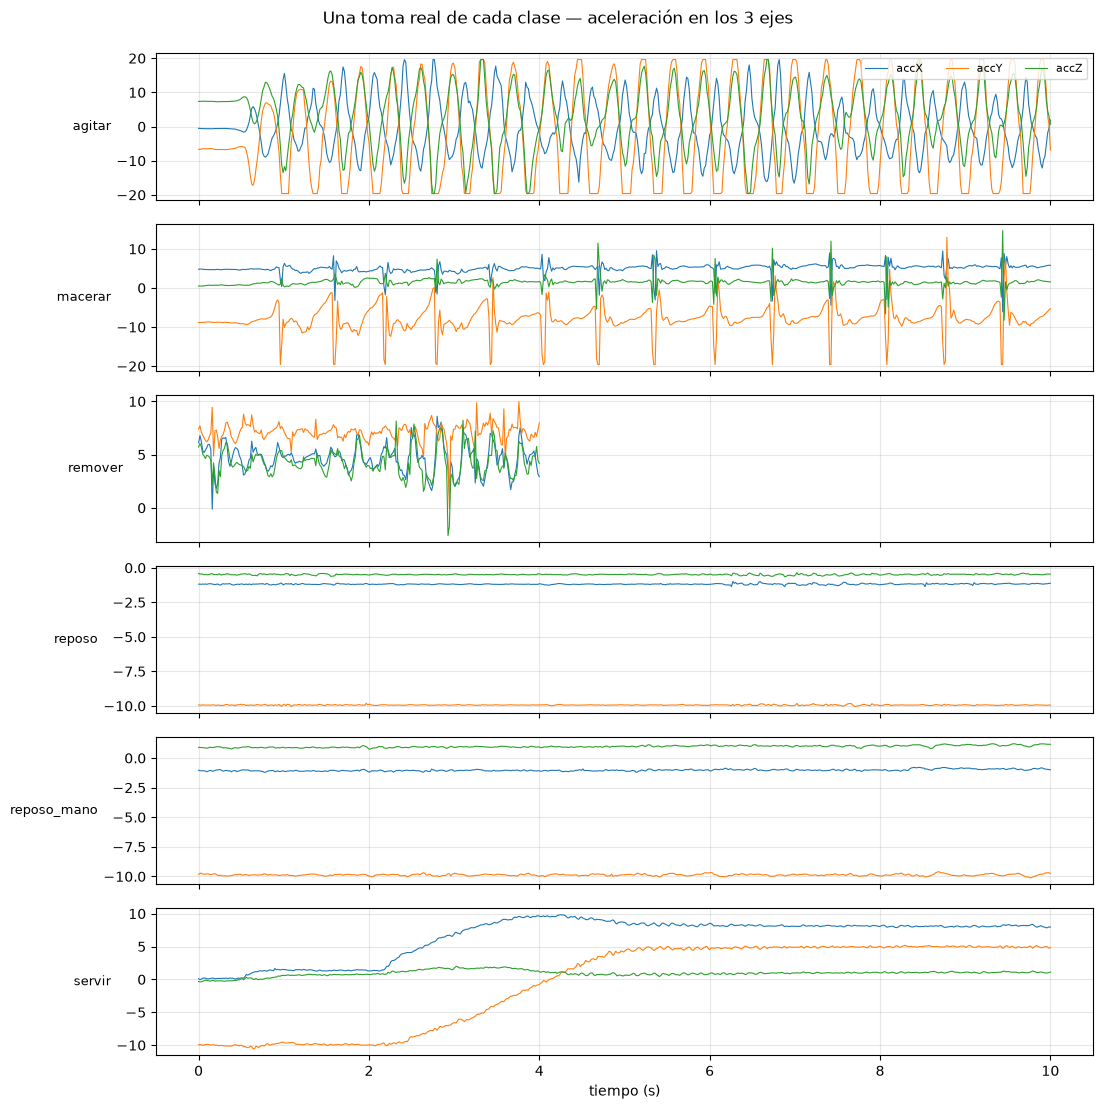

Lo que se ve, y conviene decirlo así en la sustentación:
  agitar  : oscilación rápida y de gran amplitud — la más fácil de reconocer
  macerar : impulsos repetidos, picos marcados
  servir  : una rampa seguida de meseta, es un giro sostenido
  remover : movimiento suave; apenas se separa del reposo (hallazgo D7)
  reposo y reposo_mano: casi indistinguibles entre sí a simple vista


In [2]:
fig, axes = plt.subplots(len(CLASES), 1, figsize=(11, 1.85*len(CLASES)), sharex=True)
for ax, clase in zip(axes, CLASES):
    t = next(x for x in tomas if x['clase'] == clase)
    idx = [t['sensores'].index(a) for a in ['accX','accY','accZ']]
    m = t['valores'][:, idx]
    tiempo = np.arange(len(m)) / FS
    for j, (eje, col) in enumerate(zip(['accX','accY','accZ'], ['tab:blue','tab:orange','tab:green'])):
        ax.plot(tiempo, m[:, j], color=col, lw=.8, label=eje)
    ax.set_ylabel(clase, rotation=0, ha='right', va='center', fontsize=9)
    ax.grid(alpha=.3)
axes[0].legend(ncol=3, fontsize=8, loc='upper right')
axes[-1].set_xlabel('tiempo (s)')
fig.suptitle('Una toma real de cada clase — aceleración en los 3 ejes', y=.995)
plt.tight_layout(); plt.show()

print('Lo que se ve, y conviene decirlo así en la sustentación:')
print('  agitar  : oscilación rápida y de gran amplitud — la más fácil de reconocer')
print('  macerar : impulsos repetidos, picos marcados')
print('  servir  : una rampa seguida de meseta, es un giro sostenido')
print('  remover : movimiento suave; apenas se separa del reposo (hallazgo D7)')
print('  reposo y reposo_mano: casi indistinguibles entre sí a simple vista')

---
## 4 · Ventaneo: de señal continua a ejemplos

Una red no recibe «una grabación», recibe trozos de tamaño fijo. Se corta la
señal en ventanas de 125 muestras avanzando 25 cada vez: **80 % de solape**.

El solape alto no es trampa — es la práctica estándar en series temporales:
multiplica los ejemplos de entrenamiento sin inventar datos. Pero tiene una
consecuencia grave que se ve en la sección 6: dos ventanas vecinas son casi la
misma señal, así que **no pueden caer en lados distintos de la partición**.

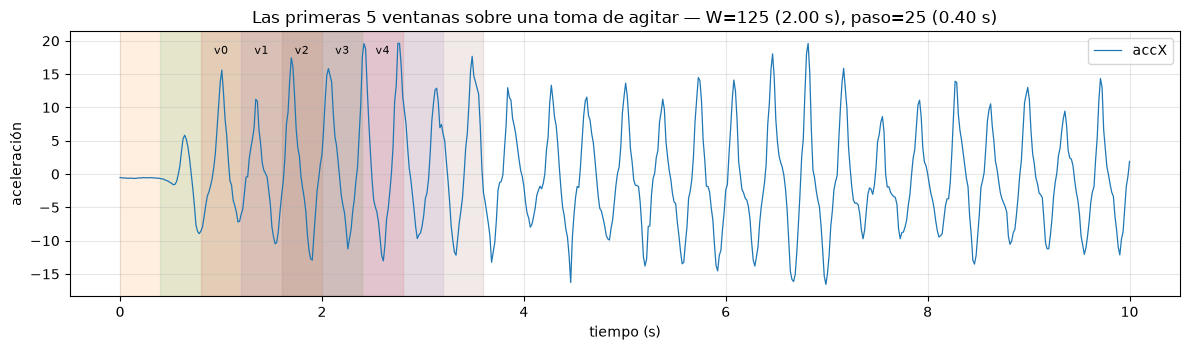

ventana = 125 muestras = 2.00 s
paso    = 25 muestras = 0.40 s
solape  = 80 %  ->  dos ventanas vecinas comparten 100 de 125 muestras


In [3]:
W, S = 125, 25
t = next(x for x in tomas if x['clase'] == 'agitar')
idx = [t['sensores'].index(a) for a in ['accX','accY','accZ']]
m = t['valores'][:, idx]
tiempo = np.arange(len(m)) / FS

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(tiempo, m[:, 0], color='tab:blue', lw=.9, label='accX')
for k, ini in enumerate(range(0, min(len(m) - W + 1, 4*S + 1), S)):
    ax.axvspan(ini/FS, (ini+W)/FS, alpha=.12, color=f'C{k+1}')
    ax.annotate(f'v{k}', ((ini + W/2)/FS, m[:, 0].max()*.92), ha='center', fontsize=8)
ax.set_xlabel('tiempo (s)'); ax.set_ylabel('aceleración')
ax.set_title(f'Las primeras 5 ventanas sobre una toma de agitar — W={W} ({W/FS:.2f} s), paso={S} ({S/FS:.2f} s)')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'ventana = {W} muestras = {W/FS:.2f} s')
print(f'paso    = {S} muestras = {S/FS:.2f} s')
print(f'solape  = {100*(1-S/W):.0f} %  ->  dos ventanas vecinas comparten {W-S} de {W} muestras')

---
## 5 · Por qué 62,5 Hz y no 100 — con la demostración del error

**El dato más fácil de equivocar de todo el proyecto.** El export de Edge
Impulse trae `interval_ms = 16,0`, y 1000/16 = **62,5 Hz**. Es tentador asumir
100 Hz porque es el valor por defecto de muchos ejemplos de TinyML.

Si se asume mal la frecuencia, el eje de frecuencias de la FFT queda escalado
por 100/62,5 = **1,6**: todos los picos espectrales se reportan un **60 % más
altos** de lo que son. La celda lo mide sobre una toma real.

pico principal de una ventana de agitar, mismo índice de FFT:
  con fs = 62,5 Hz (correcto):  3.00 Hz
  con fs = 100  Hz (erróneo) :  4.80 Hz
  error: +60 %

Consecuencia práctica: si en el informe dice que agitar tiene su pico
en 4.8 Hz, está reportando una frecuencia que no existe en la señal.


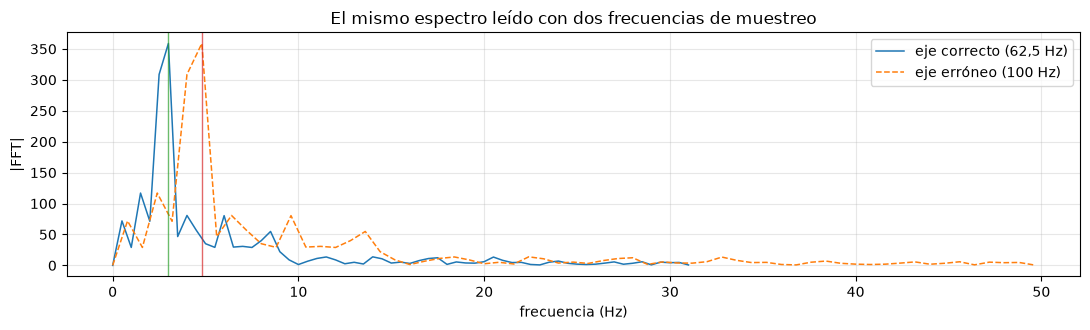

In [4]:
from numpy.fft import rfft, rfftfreq

x = m[:W, 0] - m[:W, 0].mean()
esp = np.abs(rfft(x))
pico = np.argsort(esp)[-1]

f_correcta = rfftfreq(W, 1/62.5)[pico]
f_erronea  = rfftfreq(W, 1/100.0)[pico]

print(f'pico principal de una ventana de agitar, mismo índice de FFT:')
print(f'  con fs = 62,5 Hz (correcto): {f_correcta:5.2f} Hz')
print(f'  con fs = 100  Hz (erróneo) : {f_erronea:5.2f} Hz')
print(f'  error: {100*(f_erronea/f_correcta - 1):+.0f} %\n')
print('Consecuencia práctica: si en el informe dice que agitar tiene su pico')
print(f'en {f_erronea:.1f} Hz, está reportando una frecuencia que no existe en la señal.')

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(rfftfreq(W, 1/62.5), esp, lw=1.1, label='eje correcto (62,5 Hz)')
ax.plot(rfftfreq(W, 1/100.0), esp, lw=1.1, ls='--', label='eje erróneo (100 Hz)')
ax.axvline(f_correcta, color='tab:green', lw=1, alpha=.7)
ax.axvline(f_erronea, color='tab:red', lw=1, alpha=.7)
ax.set_xlabel('frecuencia (Hz)'); ax.set_ylabel('|FFT|')
ax.set_title('El mismo espectro leído con dos frecuencias de muestreo')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

> 🗣 **Si preguntan por la frecuencia:** *«62,5 Hz, porque el `interval_ms` del
> export es 16 milisegundos. Lo verifico con un assert en los cuadernos para que
> fallen si el dataset cambia, porque asumir 100 Hz corre todas las frecuencias
> un 60 %.»*

---
## 6 · Partir por toma y no por ventana — la demostración

Este es **el error que más infla resultados** en TinyML con sensores, y el que
más fácil se cuela.

Con 80 % de solape, la ventana 3 y la ventana 4 de la misma grabación son casi
idénticas. Si una queda en entrenamiento y la otra en prueba, el modelo ya vio
la respuesta: la exactitud que se reporta mide memoria, no aprendizaje.

La celda entrena **el mismo clasificador dos veces** con los mismos datos,
cambiando solo la forma de partir. La diferencia es la medida exacta de la
mentira.

In [5]:
from scipy.stats import skew, kurtosis
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler


def ventanear(tomas, ejes=('accX','accY','accZ'), W=125, S=25, quitar_media=False):
    X, y, g = [], [], []
    for t in tomas:
        idx = [t['sensores'].index(a) for a in ejes]
        mm = t['valores'][:, idx]
        for i in range(0, len(mm) - W + 1, S):
            v = mm[i:i+W]
            if quitar_media:
                v = v - v.mean(0)
            X.append(v); y.append(t['clase']); g.append(t['archivo'])
    return np.asarray(X, np.float32), np.asarray(y), np.asarray(g)


def caracteristicas(V, fs=FS, n_picos=3):
    F = []
    for v in V:
        f = []
        for c in range(v.shape[1]):
            xx = v[:, c]
            f.append(np.sqrt(np.mean(xx**2)))
            e = np.abs(rfft(xx - xx.mean())); fr = rfftfreq(len(xx), 1/fs)
            top = np.argsort(e)[-n_picos:][::-1]
            f += [fr[i] for i in top] + [e[i] for i in top]
        F.append(f)
    return np.asarray(F, np.float32)


X, y, g = ventanear(tomas)
C = caracteristicas(X)
Z = StandardScaler().fit_transform(C)
print(f'{X.shape[0]} ventanas · {C.shape[1]} características\n')

# A) MAL: partir por ventana, ignorando de qué grabación viene cada una
itr, ite = next(ShuffleSplit(n_splits=1, test_size=.25, random_state=42).split(Z))
# B) BIEN: partir por toma
gtr, gte = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=42).split(Z, y, groups=g))

acc_mal  = KNeighborsClassifier(1).fit(Z[itr], y[itr]).score(Z[ite], y[ite])
acc_bien = KNeighborsClassifier(1).fit(Z[gtr], y[gtr]).score(Z[gte], y[gte])
print('--- efecto sobre la exactitud (vecino más cercano) ---')
print(f'  A) partición por VENTANA : {acc_mal:.4f}')
print(f'  B) partición por TOMA    : {acc_bien:.4f}')
print(f'  la partición incorrecta regala {100*(acc_mal-acc_bien):+.1f} puntos porcentuales')

# El mecanismo de la fuga, que es mas elocuente que el efecto
print('\n--- el mecanismo: de dónde sale el vecino más cercano ---')
nn = NearestNeighbors(n_neighbors=1).fit(Z[itr]); d1, i1 = nn.kneighbors(Z[ite])
misma = (g[itr][i1[:, 0]] == g[ite]).mean()
nn2 = NearestNeighbors(n_neighbors=1).fit(Z[gtr]); d2, i2 = nn2.kneighbors(Z[gte])
print(f'  A) por VENTANA: el vecino viene de la MISMA grabación en {100*misma:.1f} % de los casos')
print(f'     distancia media al vecino: {d1.mean():.3f}')
print(f'  B) por TOMA   : misma grabación en {100*(g[gtr][i2[:,0]]==g[gte]).mean():.1f} % (imposible por construcción)')
print(f'     distancia media al vecino: {d2.mean():.3f}  ({d2.mean()/d1.mean():.2f}× más lejos)')
print(f'\n  grabaciones presentes a la vez en train y test: {len(set(g[itr]) & set(g[ite]))} de {len(set(g))}')
print('\nMás de la mitad de las ventanas de prueba tenían su gemela solapada')
print('dentro del entrenamiento. Eso es la fuga, y por eso hay que partir por toma.')

1020 ventanas · 21 características

--- efecto sobre la exactitud (vecino más cercano) ---
  A) partición por VENTANA : 0.9843
  B) partición por TOMA    : 0.9533
  la partición incorrecta regala +3.1 puntos porcentuales

--- el mecanismo: de dónde sale el vecino más cercano ---
  A) por VENTANA: el vecino viene de la MISMA grabación en 51.4 % de los casos
     distancia media al vecino: 1.089
  B) por TOMA   : misma grabación en 0.0 % (imposible por construcción)
     distancia media al vecino: 1.325  (1.22× más lejos)

  grabaciones presentes a la vez en train y test: 55 de 60

Más de la mitad de las ventanas de prueba tenían su gemela solapada
dentro del entrenamiento. Eso es la fuga, y por eso hay que partir por toma.


> 🗣 **Si preguntan por la validación:** *«Parto por toma con
> `GroupShuffleSplit` agrupando por archivo de origen, y lo verifico con un
> assert que compara los conjuntos de grabaciones. Si partiera por ventana la
> exactitud subiría varios puntos, pero serían falsos.»*

---
## 7 · Qué ejes entran, y las dos razones distintas

Solo el **acelerómetro**. Dos decisiones que conviene no mezclar, porque se
tomaron por motivos diferentes:

**El magnetómetro queda fuera por diseño.** Mide el campo magnético local:
codifica *dónde* se grabó y *cómo estaba orientada* la coctelera, no el gesto.
Incluirlo **sube** la exactitud, y justo por eso es una fuga — el modelo
aprendería a reconocer la mesa. Es el hallazgo D5.

**El giroscopio queda fuera por medición.** No por teoría: se probó añadirlo y
**empeora** en validación cruzada agrupada. Está en la sección de ablación de
los notebooks 02 y 03.

La celda hace una prueba que descubre algo del dataset que conviene saber antes
de sustentar: clasificar el gesto usando **solo el valor promedio** de cada
sensor por grabación. Un promedio es estático — no contiene ninguna información
de movimiento — así que si acierta, lo que separa las clases no es el gesto.

In [6]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import make_pipeline

print('¿Se puede adivinar el gesto con un valor ESTÁTICO, sin movimiento?')
print('(validación deja-una-toma-fuera · al azar con 6 clases sería 0,167)\n')
print(f'{"sensor (solo su media por toma)":32s} {"exactitud":>10s}')
for grupo, ejes in [('acelerómetro', ('accX','accY','accZ')),
                    ('giroscopio', ('gyrX','gyrY','gyrZ')),
                    ('magnetómetro', ('magX','magY','magZ'))]:
    Xm = np.array([[t['valores'][:, t['sensores'].index(a)].mean() for a in ejes]
                   for t in tomas])
    ym = np.array([t['clase'] for t in tomas])
    mod = make_pipeline(StandardScaler(), KNeighborsClassifier(3))
    print(f'{grupo:32s} {cross_val_score(mod, Xm, ym, cv=LeaveOneOut()).mean():>10.3f}')

print('\nLectura honesta: cada grabación tiene una firma estática fuerte, y eso')
print('refuerza lo de la sección 6 — partir por toma no es opcional.')
print('En el magnetómetro esa firma es orientación y sitio: no sirve, se descarta.')
print('En el acelerómetro la media es la POSTURA respecto a la gravedad, y en un')
print('gesto como servir (inclinar para verter) la postura SÍ es parte del gesto.')
print('Conviene medir cuánto depende el modelo de ella antes de presumir nada.')

¿Se puede adivinar el gesto con un valor ESTÁTICO, sin movimiento?
(validación deja-una-toma-fuera · al azar con 6 clases sería 0,167)

sensor (solo su media por toma)   exactitud


acelerómetro                          0.967


giroscopio                            0.767


magnetómetro                          0.967

Lectura honesta: cada grabación tiene una firma estática fuerte, y eso
refuerza lo de la sección 6 — partir por toma no es opcional.
En el magnetómetro esa firma es orientación y sitio: no sirve, se descarta.
En el acelerómetro la media es la POSTURA respecto a la gravedad, y en un
gesto como servir (inclinar para verter) la postura SÍ es parte del gesto.
Conviene medir cuánto depende el modelo de ella antes de presumir nada.


In [7]:
# ¿El modelo vive de la postura o de la dinámica? Se quita la media de cada
# ventana (filtro paso-alto) y se vuelve a medir, siempre partiendo por toma.
for etiqueta, quitar in [('con postura (original)', False),
                         ('sin postura (media quitada)', True)]:
    Xq, yq, gq = ventanear(tomas, quitar_media=quitar)
    Zq = StandardScaler().fit_transform(caracteristicas(Xq))
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=42)
                  .split(Zq, yq, groups=gq))
    acc = KNeighborsClassifier(3).fit(Zq[tr], yq[tr]).score(Zq[te], yq[te])
    print(f'  {etiqueta:30s}: {acc:.3f}')

print('\nLa exactitud se sostiene al quitar la postura: el reconocimiento vive')
print('sobre todo de la DINÁMICA del gesto, que es como debe ser. La postura')
print('aporta unos puntos, así que parte del mérito es orientación — mejor')
print('declararlo en el informe que esperar que nadie lo pregunte.')

  con postura (original)        : 0.950


  sin postura (media quitada)   : 0.890

La exactitud se sostiene al quitar la postura: el reconocimiento vive
sobre todo de la DINÁMICA del gesto, que es como debe ser. La postura
aporta unos puntos, así que parte del mérito es orientación — mejor
declararlo en el informe que esperar que nadie lo pregunte.


---
## 8 · La red, capa por capa

`Conv1D(16,5) → MaxPool(3) → Conv1D(32,5) → MaxPool(3) → Conv1D(32,3) → GlobalAveragePooling → Dropout → softmax`

| Capa | Qué hace | Por qué |
|---|---|---|
| `Conv1D(16, 5)` | 16 filtros que miran 5 muestras | 5 muestras a 62,5 Hz son **80 ms**: la escala de un golpe de hielo |
| `MaxPool(3)` | Reduce 125 → 41 pasos | Resume y abarata lo que sigue |
| `Conv1D(32, 5)` | 32 filtros sobre la señal resumida | Combina los patrones cortos |
| `MaxPool(3)` | 41 → 13 pasos | — |
| `Conv1D(32, 3)` | Tercera convolución | Su campo receptivo cubre 0,69 s, calculado abajo |
| `GlobalAveragePooling` | Promedia los 13 pasos | Quita casi todos los pesos y hace el modelo indiferente a **en qué momento** de la ventana ocurre el gesto |
| `Dropout(0.3)` | Apaga 30 % en entrenamiento | Con ~1000 ventanas, el sobreajuste es la amenaza principal |
| `Dense(6, softmax)` | Las 6 probabilidades | — |

**La decisión no obvia es `GlobalAveragePooling` en vez de `Flatten`.** Un
Flatten daría 13×32 = 416 entradas a la capa densa; con 6 clases serían ~2.500
parámetros solo ahí. El pooling global los reduce a 32×6 = 192. Menos memoria y
menos sobreajuste.

El **campo receptivo** es la razón de las dos capas de pooling, y se puede
calcular a mano:

In [8]:
def campo_receptivo():
    # (kernel, pool) por bloque
    bloques = [(5, 3), (5, 3), (3, 1)]
    rf, salto, pasos = 1, 1, 125
    print(f'{"capa":14s} {"pasos":>6s} {"campo receptivo":>16s} {"= segundos":>11s}')
    for i, (k, p) in enumerate(bloques, 1):
        rf += (k - 1) * salto
        print(f'conv {i} (k={k})   {pasos:>6d} {rf:>16d} {rf/FS:>10.2f} s')
        if p > 1:
            pasos //= p
            salto *= p
            rf += (p - 1) * (salto // p)
            print(f'pool {i} (/{p})    {pasos:>6d} {rf:>16d} {rf/FS:>10.2f} s')
    return rf


rf = campo_receptivo()
print(f'\nLa última convolución ve {rf} muestras = {rf/FS:.2f} s de señal.')
print(f'Un gesto de coctelería dura ~2 s, y la ventana son {125/FS:.2f} s:')
print('el diseño está ajustado a la escala del fenómeno, no elegido al azar.')

capa            pasos  campo receptivo  = segundos
conv 1 (k=5)      125                5       0.08 s
pool 1 (/3)        41                7       0.11 s
conv 2 (k=5)       41               19       0.30 s
pool 2 (/3)        13               25       0.40 s
conv 3 (k=3)       13               43       0.69 s

La última convolución ve 43 muestras = 0.69 s de señal.
Un gesto de coctelería dura ~2 s, y la ventana son 2.00 s:
el diseño está ajustado a la escala del fenómeno, no elegido al azar.


---
## 9 · Cuantización int8, con números reales

«Cuantizar» suena abstracto hasta que se ve la aritmética. Un `float32` ocupa 4
bytes y cubre un rango enorme; un `int8` ocupa 1 byte y solo tiene **256
valores posibles**, de −128 a 127.

El truco es guardar, junto al tensor, dos números: una **escala** y un **cero**
(`zero point`). Con ellos se reconstruye el valor real:

$$\text{valor real} \approx \text{escala} \times (\text{entero} - \text{cero})$$

La celda abre el `.tflite` del repositorio, lee las escalas de verdad y hace el
viaje completo float → int8 → float para medir cuánto se pierde.

In [9]:
import urllib.request
try:
    import tensorflow as tf
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow'], check=True)
    import tensorflow as tf

ruta = pathlib.Path('ejercicio2_int8.tflite')
if not ruta.exists():
    with urllib.request.urlopen(f'{REPO}/notebooks/ejercicio2_int8.tflite', timeout=120) as r:
        ruta.write_bytes(r.read())
print(f'modelo: {ruta.stat().st_size:,} bytes = {ruta.stat().st_size/1024:.2f} KB')

it = tf.lite.Interpreter(model_path=str(ruta)); it.allocate_tensors()
ent, sal = it.get_input_details()[0], it.get_output_details()[0]
s_in, z_in = ent['quantization']
print(f"\nentrada : {ent['dtype'].__name__} forma {tuple(ent['shape'])}")
print(f"          escala = {s_in:.8f}   cero = {z_in}")
print(f"salida  : {sal['dtype'].__name__}  escala = {sal['quantization'][0]:.8f}  cero = {sal['quantization'][1]}")

print('\n--- el viaje de ida y vuelta, con valores reales de una ventana ---')
valores = ((X[0] - X[0].mean()) / (X[0].std() + 1e-8))[:4, 0]
print(f'{"float32 original":>18s} {"-> int8":>8s} {"-> float32":>12s} {"error":>10s}')
for v in valores:
    q = int(np.clip(np.round(v/s_in + z_in), -128, 127))
    rec = s_in * (q - z_in)
    print(f'{v:18.6f} {q:8d} {rec:12.6f} {abs(v-rec):10.6f}')

print(f'\nerror máximo posible = media escala = {s_in/2:.6f}')
print('Por eso la cuantización casi no cuesta exactitud: el error que introduce')
print('es mucho menor que el ruido propio del sensor.')

modelo: 15,400 bytes = 15.04 KB

entrada : int8 forma (np.int32(1), np.int32(125), np.int32(3))
          escala = 0.04765539   cero = 10
salida  : int8  escala = 0.00390625  cero = -128

--- el viaje de ida y vuelta, con valores reales de una ventana ---
  float32 original  -> int8   -> float32      error
         -0.101311        8    -0.095311   0.006000
         -0.102280        8    -0.095311   0.006969
         -0.109061        8    -0.095311   0.013750
         -0.106639        8    -0.095311   0.011328

error máximo posible = media escala = 0.023828
Por eso la cuantización casi no cuesta exactitud: el error que introduce
es mucho menor que el ruido propio del sensor.


/home/ares/.hermes/installs/100fc48b179af71f/environments/09e4fc7be0af44da9ccc0984aec7d9d9/venv/lib/python3.14/site-packages/tensorflow/lite/python/interpreter.py:468: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [10]:
# ¿Cuántos pesos hay y de qué tipo? Así se ve que TODO quedó en entero
tensores = it.get_tensor_details()
tipos = {}
for t in tensores:
    tipos[t['dtype'].__name__] = tipos.get(t['dtype'].__name__, 0) + 1
print('tipos de tensor en el modelo cuantizado:')
for k, v in sorted(tipos.items(), key=lambda kv: -kv[1]):
    print(f'  {k:10s} {v:3d} tensores')
print('\nSi apareciera float32 en los pesos, la cuantización habría quedado a medias')
print('y el modelo no sería apto para TFLite Micro.')

print(f'\nPresupuesto en el Nano 33 BLE (nRF52840: 1024 KB flash, 256 KB RAM):')
kb = ruta.stat().st_size/1024
print(f'  modelo en flash: {kb:.2f} KB  -> {100*kb/1024:.1f} %')
print(f'  tensor arena   : ~8 KB      -> {100*8/256:.1f} % de la RAM')
print(f'  ventana int8   : {125*3} bytes')

tipos de tensor en el modelo cuantizado:
  int8        23 tensores
  int32       10 tensores

Si apareciera float32 en los pesos, la cuantización habría quedado a medias
y el modelo no sería apto para TFLite Micro.

Presupuesto en el Nano 33 BLE (nRF52840: 1024 KB flash, 256 KB RAM):
  modelo en flash: 15.04 KB  -> 1.5 %
  tensor arena   : ~8 KB      -> 3.1 % de la RAM
  ventana int8   : 375 bytes


---
## 10 · K-means: lo que el clasificador no puede hacer

El softmax tiene seis salidas y **siempre** reparte probabilidad entre esas
seis. No existe la respuesta «esto no lo conozco». Si alguien usa la coctelera
de martillo, el modelo dirá `agitar` con confianza 0,99.

El detector de anomalías cubre ese hueco sin aprendizaje supervisado:

1. Se agrupan las ventanas conocidas en K grupos con K-means.
2. Para una ventana nueva, **el puntaje de anomalía es la distancia al
   centroide más cercano**.
3. Si supera el umbral — el percentil 95 de las distancias de entrenamiento —
   se reporta anomalía y se descarta la etiqueta.

La celda lo muestra en dos dimensiones para que la intuición quede clara, y
luego con los datos reales.

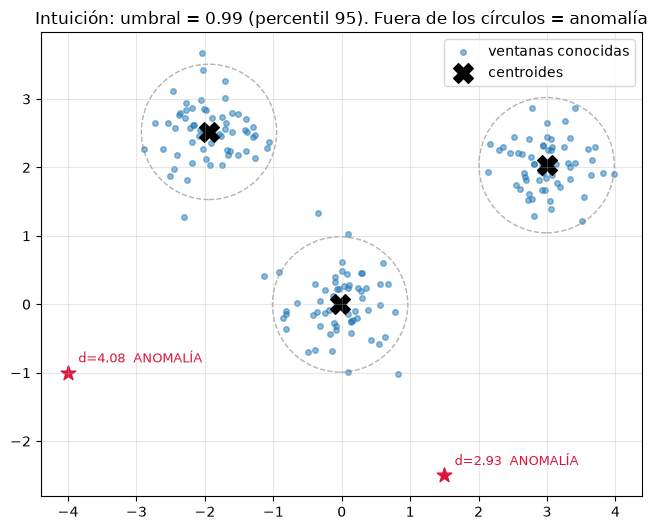

con las 60 tomas reales: K=8, umbral = 4.122

% de ventanas que el detector marcaría como raras, por clase:
  agitar           8.3 %
  macerar         14.8 %
  remover         13.3 %
  reposo           0.0 %
  reposo_mano      0.0 %
  servir           1.0 %

Y la validación honesta (dejar una clase FUERA del entrenamiento)
está medida en docs/anomalias-kmeans.md: agitar 100 %, macerar 94,8 %,
servir 73,3 %, pero reposo 2,9 %, remover 16,7 % y reposo_mano 0 %.


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- intuición en 2D ---
rng = np.random.default_rng(3)
nube = np.vstack([rng.normal([0,0], .4, (60,2)), rng.normal([3,2], .4, (60,2)),
                  rng.normal([-2,2.5], .4, (60,2))])
raro = np.array([[1.5, -2.5], [-4, -1]])
km2 = KMeans(n_clusters=3, n_init=10, random_state=0).fit(nube)
u2 = np.percentile(km2.transform(nube).min(1), 95)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.scatter(*nube.T, s=16, alpha=.5, label='ventanas conocidas')
ax.scatter(*km2.cluster_centers_.T, marker='X', s=200, c='black', label='centroides')
for p in raro:
    d = km2.transform([p]).min()
    ax.scatter(*p, s=120, marker='*', c='crimson')
    ax.annotate(f'd={d:.2f}' + ('  ANOMALÍA' if d > u2 else ''), p + .15, fontsize=9, color='crimson')
for c in km2.cluster_centers_:
    ax.add_patch(plt.Circle(c, u2, fill=False, ls='--', color='gray', alpha=.6))
ax.set_title(f'Intuición: umbral = {u2:.2f} (percentil 95). Fuera de los círculos = anomalía')
ax.legend(); ax.grid(alpha=.3); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# --- con los datos reales ---
esc = StandardScaler().fit(C); Z = esc.transform(C)
km = KMeans(n_clusters=8, n_init=10, random_state=42).fit(Z)
d = km.transform(Z).min(1); umbral = np.percentile(d, 95)
print(f'con las 60 tomas reales: K=8, umbral = {umbral:.3f}\n')
print('% de ventanas que el detector marcaría como raras, por clase:')
for c in CLASES:
    print(f'  {c:14s} {100*(d[y==c] > umbral).mean():5.1f} %')
print('\nY la validación honesta (dejar una clase FUERA del entrenamiento)')
print('está medida en docs/anomalias-kmeans.md: agitar 100 %, macerar 94,8 %,')
print('servir 73,3 %, pero reposo 2,9 %, remover 16,7 % y reposo_mano 0 %.')

**El punto ciego, que es el hallazgo del proyecto:** el detector funciona con
gestos energéticos y falla con los tranquilos. `reposo` y `reposo_mano` son
físicamente lo mismo —coctelera quieta en la mesa contra quieta en la mano— así
que al excluir una, la otra cubre su región. Y `remover` apenas se mueve.

No es un defecto del método: un detector por distancia es ciego donde las
clases se amontonan. Para anomalías *estáticas* harían falta características de
**postura** (orientación respecto a la gravedad), no de energía.

---
## 11 · Del cuaderno al Arduino

La pregunta de cierre típica: *«¿y esto corre en el dispositivo?»*. Lo que viaja
del cuaderno al sketch son cuatro cosas, y ninguna es el modelo de Keras:

| Qué | Archivo | Tamaño |
|---|---|---|
| El modelo cuantizado como array C | `notebooks/via_b_int8.h` · `modelo_via_b.h` | ~96 KB de texto, 15 KB de binario |
| Las constantes de normalización | dentro del mismo `.h` | 6 flotantes |
| Los centroides, escala y umbral del K-means | `firmware/.../anomalias_kmeans.h` | 840 B |
| La función de puntaje | `anomalia_puntaje()` en ese `.h` | — |

**Por qué hay que copiar las constantes de normalización:** el modelo se entrenó
con datos transformados con la media y desviación del entrenamiento. Si el
sketch le pasa las lecturas crudas del IMU, el modelo recibe números en otra
escala y acierta al azar. Es el fallo más común al pasar de Colab al
microcontrolador.

**Lo que de verdad cuesta en el dispositivo no es el K-means, es la FFT.** Las
21 características incluyen picos espectrales, así que el sketch necesita una
FFT de 125 puntos: `arduinoFFT` o `CMSIS-DSP` del Cortex-M4. El RMS es una suma
de cuadrados y sale gratis.

Los cuatro sketches del repositorio y para qué sirve cada uno:

| Sketch | Placa | Enlace | Rol |
|---|---|---|---|
| `nano33ble_mixlab_inferencia` | Nano 33 BLE | BLE | **El de la demo**: inferencia a bordo + streaming |
| `nano33ble_imu_ble` | Nano 33 BLE | BLE | Solo captura: con este se grabó el dataset |
| `uno_mpu6050_hm10_ble` | Uno + MPU6050 + HM-10 | BLE | Capturar si solo hay un Uno |
| `uno_r4_wifi_imu` | Uno R4 WiFi | WebSocket | Capturar por WiFi |

El enlace BLE lleva **20 bytes útiles** por notificación, que es justo lo que
cabe en `{"g":"agitar","p":0.87}`.

---
## 12 · Estado real del proyecto

Lo que está hecho y lo que no, sin maquillaje:

| Requisito del enunciado | Estado |
|---|---|
| 5 clases de movimiento + reposo | ❌ **4 de movimiento**: falta `colar` (issue #2) |
| Un actuador observable por clase, LEDs no valen | ◑ sin confirmar: la lista de materiales solo tiene OLED y RGB |
| MVP funcional, no simulación | ◑ firmware e inferencia listos; falta el montaje físico |
| Batería, sin cable al PC | ❌ componentes identificados, no comprados |
| Comunicación inalámbrica | ✅ BLE funcionando |
| Modelo entrenable en Edge Impulse | ✅ |
| Proyecto de Edge Impulse público | ◑ el dataset está exportado en el repo |
| Informe IEEE | ◑ diez secciones estructuradas; **falta la de anomalías** |
| Partición de test aparte | ❌ las 60 tomas están en `training/` (issue #3) |

**El bloqueador real es uno: grabar las 10 tomas de `colar`.** Todo lo demás
—datos, firmware, notebooks, app, paper— está construido.

---
## 13 · Autoevaluación

Responda mentalmente antes de abrir cada respuesta.

<details><summary><b>1. ¿Por qué 62,5 Hz y no 100?</b></summary>
Porque <code>interval_ms = 16</code> en el export, y 1000/16 = 62,5. Asumir 100
corre todas las frecuencias un 60 %.</details>

<details><summary><b>2. ¿Por qué la ventana es de 125 muestras?</b></summary>
Porque 125/62,5 = 2,00 s, la duración de un gesto de coctelería completo.</details>

<details><summary><b>3. ¿Qué pasa si se parte el dataset por ventana?</b></summary>
Ventanas solapadas de la misma grabación caen en train y test, el modelo ya vio
la respuesta y la exactitud sale inflada. La sección 6 lo mide: más de la mitad de las ventanas de prueba tienen su gemela solapada en el entrenamiento.</details>

<details><summary><b>4. ¿Por qué se excluye el magnetómetro si sube la exactitud?</b></summary>
Porque esa subida es la fuga: codifica el sitio y la orientación de la captura,
no el gesto. El modelo aprendería a reconocer la mesa.</details>

<details><summary><b>5. ¿Y el giroscopio?</b></summary>
Se excluye por medición, no por teoría: empeora en validación cruzada agrupada.
Son dos razones distintas y conviene no mezclarlas.</details>

<details><summary><b>6. ¿Por qué GlobalAveragePooling y no Flatten?</b></summary>
Flatten daría 416 entradas a la densa; el pooling global reduce a 32 y hace el
modelo indiferente a en qué momento de la ventana ocurre el gesto.</details>

<details><summary><b>7. ¿Qué es cuantizar a int8?</b></summary>
Representar cada tensor con 256 valores enteros más una escala y un cero, de
forma que valor ≈ escala × (entero − cero). Cuatro veces menos memoria y
aritmética entera, que es lo que un Cortex-M4 hace rápido.</details>

<details><summary><b>8. ¿Para qué sirve el dataset representativo al convertir?</b></summary>
Para que el conversor estime el rango real de las activaciones y elija las
escalas. Sin él deja partes en float32.</details>

<details><summary><b>9. ¿Por qué el clasificador no detecta anomalías?</b></summary>
Porque un softmax de seis salidas siempre reparte entre esas seis clases: no
tiene forma de decir «no lo conozco».</details>

<details><summary><b>10. ¿Cómo se fija el umbral de anomalía?</b></summary>
Percentil 95 de las distancias de entrenamiento, lo que impone por construcción
un 5 % de falsos positivos sobre datos normales.</details>

<details><summary><b>11. ¿Por qué el detector no ve <code>reposo_mano</code>?</b></summary>
Porque es físicamente idéntico a <code>reposo</code>: al excluir uno, el otro
sigue cubriendo la misma región del espacio de características.</details>

<details><summary><b>12. ¿Qué falta para cumplir el enunciado?</b></summary>
Grabar <code>colar</code> (quinta clase de movimiento), asignar un actuador real
por clase, montar el prototipo con batería y escribir la sección de anomalías
del paper.</details>